In [2]:
!pip install numpy pandas scipy matplotlib seaborn statsmodels scikit-learn --break-system-packages

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 26.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.5/12.5 MB 33.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.2/25.2 MB 44.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 38.0 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 14.8 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 23.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 22.6 MB/s eta 0:00:00


In [1]:
import pandas as pd

# Display all columns
pd.set_option('display.max_columns', None)

# Ensure printing of all output for each cell
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

# Week 1

## Walkthrough 1.1: Getting Started

### Setting Up the Python Environment

If you haven't already installed Python, Jupyter, and the necessary packages, there are instructions on the course repo in the README to do so [here](https://github.com/ismayc/oreilly-statistical-modeling-and-inference-with-python/blob/main/README.md). 

If you aren't able to do this on your machine, you may want to check out [Google Colab](https://colab.research.google.com/). It's a free service that allows you to run Jupyter notebooks in the cloud.

In [2]:
# Importing libraries/modules and aliasing them as needed
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

### Load a dataset

In [4]:
# Load in the dataset
spotify_sample = pd.read_csv("spotify_sample.csv")

### Prepare data

In [5]:
# Select a single feature and target variable
X = spotify_sample[['acousticness']]
y = spotify_sample['energy']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2024
)

### Train and use the model

Mean Squared Error: 0.022725844170862923
R^2 Score: 0.37411362686731475


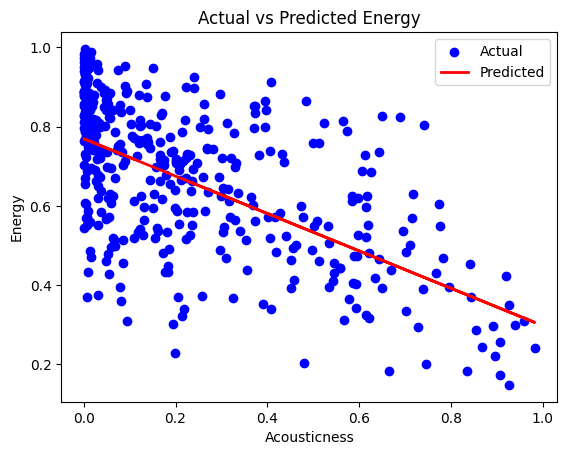

In [6]:
# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2}")

plt.clf()

# Plotting the results
plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Predicted')
plt.xlabel('Acousticness')
plt.ylabel('Energy')
plt.title('Actual vs Predicted Energy')
plt.legend()
plt.show();

### Check if assumptions of linear regression met with visual tools

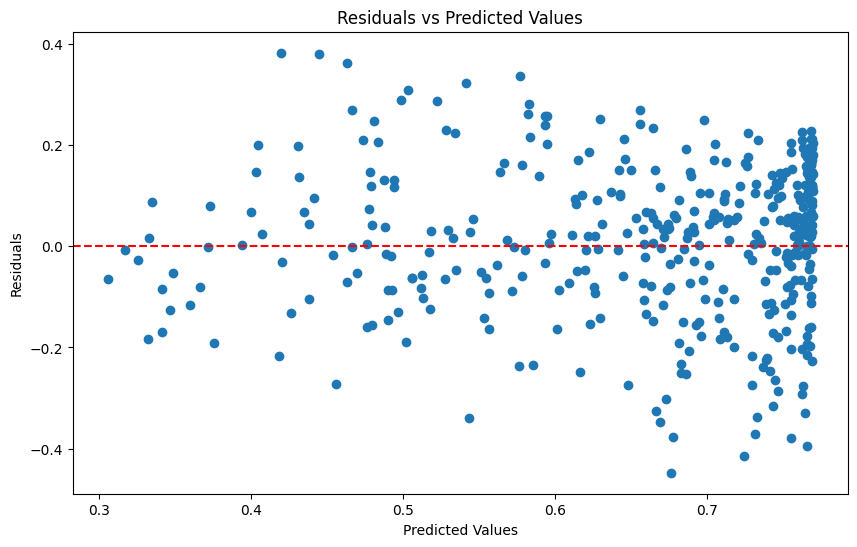

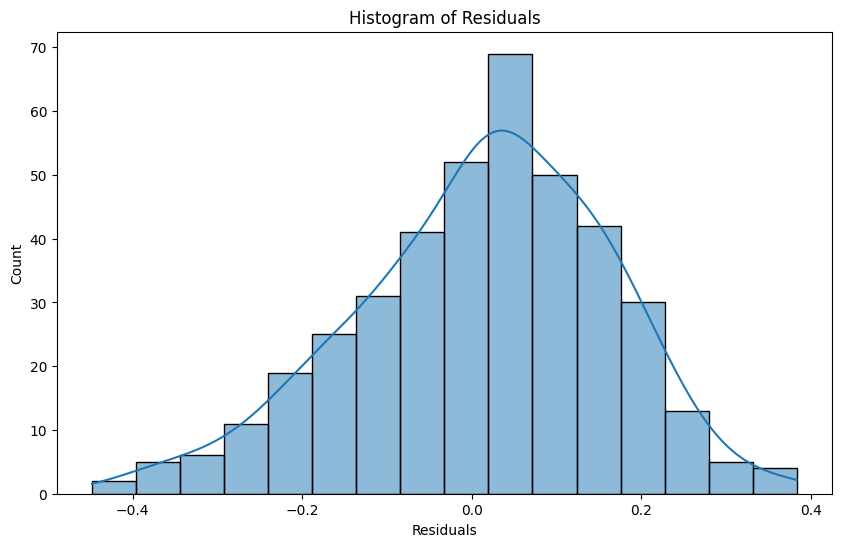

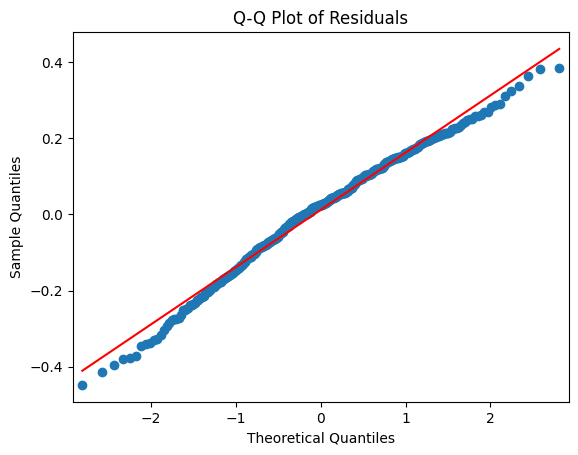

In [7]:
# Check for Homoscedasticity
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values')
plt.show();

# Check for Normality of Residuals
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.xlabel('Residuals')
plt.title('Histogram of Residuals')
plt.show();

sm.qqplot(residuals, line='s')
plt.title('Q-Q Plot of Residuals')
plt.show();

## Exercise 1.1: Getting Started

### Setting Up the Python Environment

If you ran the `# Importing libraries and aliasing them` code above, you should 
be good to proceed here. If not, scroll up and run it.

### Load a dataset

In [ ]:
# Load in the dataset
imdb_movie_sample = pd.read_csv("imdb_movie_sample.csv")

### Prepare data

In [ ]:
# Select a single feature (votes) and target variable (rating)


# Split the data into training and testing (0.2 size) sets
# with seed of 2024



### Train and use the model

In [ ]:
# Create and train the model


# Make predictions


# Evaluate the model




# Plotting the results




### Check if assumptions of linear regression met with visual tools

In [ ]:
# Check for Homoscedasticity


# Check for Normality of Residuals




## Walkthrough 1.2: Correlation

### Correlation matrix

In [8]:
# Select only numeric columns
numeric_columns = spotify_sample.select_dtypes(include=[np.number])

# Calculate Pearson correlation matrix
correlation_matrix = numeric_columns.corr()

# Display the correlation matrix
correlation_matrix

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
popularity,1.000000,-0.082278,0.127532,0.010058,-0.027631,0.086216,-0.035483,0.044336,-0.066714,-0.056118,-0.008901,-0.020808,-0.009479,-0.006527
duration_ms,-0.082278,1.000000,-0.264755,0.008741,0.028283,-0.083199,0.047103,-0.125077,-0.047906,0.028249,-0.015372,-0.132867,-0.036287,-0.056409
danceability,0.127532,-0.264755,1.000000,0.079812,0.032541,0.222743,-0.128635,0.229544,-0.092686,-0.169265,-0.064824,0.418431,-0.129809,0.225751
energy,0.010058,0.008741,0.079812,1.000000,0.010671,0.722339,-0.082894,0.101975,-0.634235,-0.149437,0.155328,0.373744,0.149471,0.209150
key,-0.027631,0.028283,0.032541,0.010671,1.000000,0.009225,-0.120635,0.067418,0.003188,0.014540,-0.009253,0.007458,-0.011600,-0.024072
loudness,0.086216,-0.083199,0.222743,0.722339,0.009225,1.000000,-0.094020,0.094559,-0.476257,-0.340739,0.101894,0.245695,0.097394,0.230465
mode,-0.035483,0.047103,-0.128635,-0.082894,-0.120635,-0.094020,1.000000,-0.064826,0.106039,0.048699,0.007828,-0.010206,-0.018432,-0.056068
speechiness,0.044336,-0.125077,0.229544,0.101975,0.067418,0.094559,-0.064826,1.000000,-0.052236,-0.066858,0.027345,0.104855,0.132441,0.079879
acousticness,-0.066714,-0.047906,-0.092686,-0.634235,0.003188,-0.476257,0.106039,-0.052236,1.000000,0.125129,-0.090550,-0.203975,-0.129973,-0.188187
instrumentalness,-0.056118,0.028249,-0.169265,-0.149437,0.014540,-0.340739,0.048699,-0.066858,0.125129,1.000000,-0.042264,-0.155218,-0.035381,-0.131703


### Visualizing correlation matrix

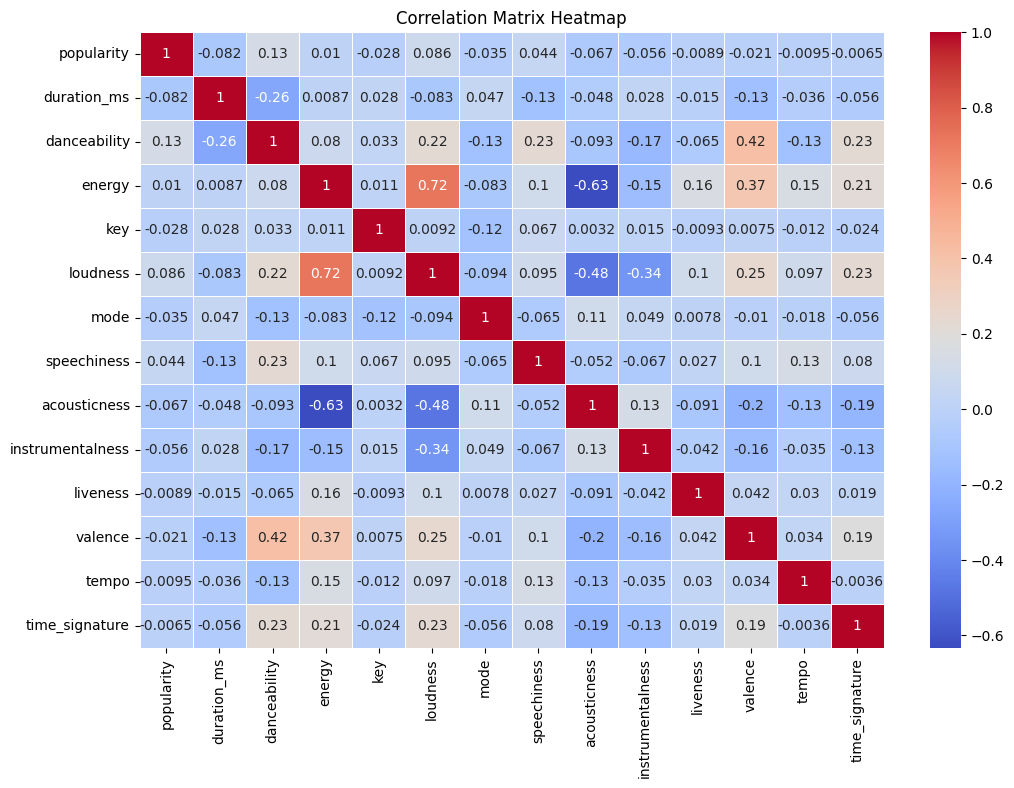

In [9]:
# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show();

### Visualizing relationships

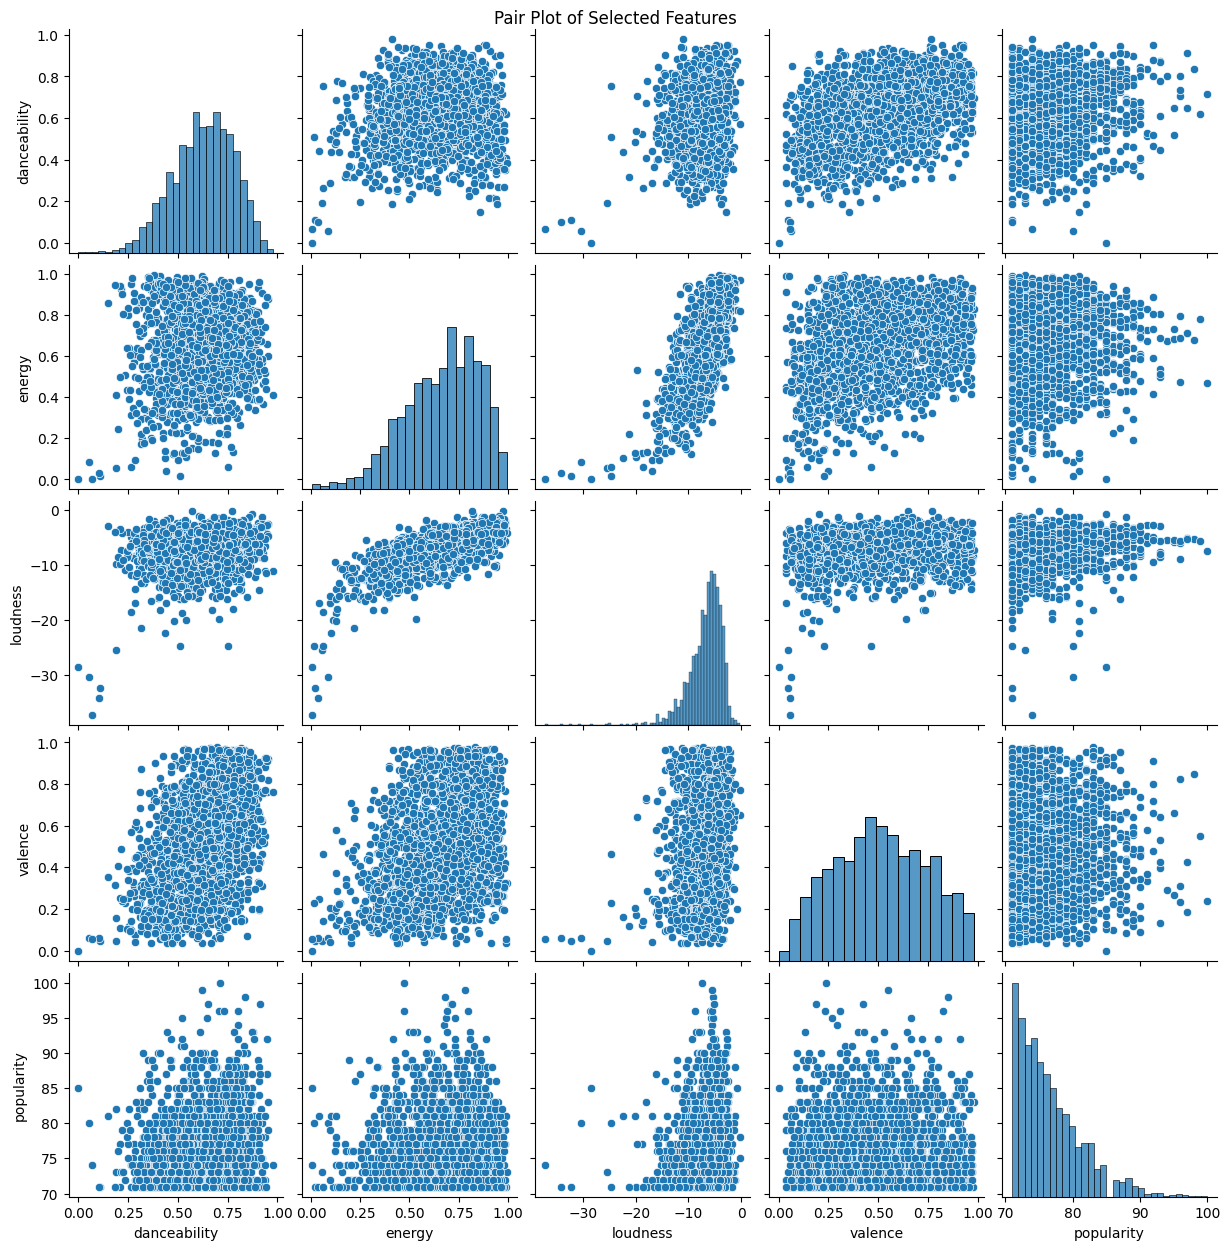

In [10]:
# Plot pairplot to visualize relationships
# between 'danceability', 'energy', 'loudness', 'valence', 'popularity'
sns.pairplot(numeric_columns[['danceability', 'energy', 'loudness', 'valence', 'popularity']]);
plt.suptitle('Pair Plot of Selected Features', y=1)
plt.show();

## Exercise 1.2: Correlation

### Correlation matrix

In [ ]:
# Select only numeric columns

# Calculate Pearson correlation matrix

# Display the correlation matrix



## Visualizing correlation matrix

In [ ]:
# Visualize the correlation matrix using a heatmap


### Visualizing relationships

In [ ]:
# Plot pairplot to visualize relationships of 
# runtime_in_minutes, rating, votes, and gross_in_dollars



## Walkthrough 1.3: Multiple Regression

In [11]:
# Prepare the data for multiple regression
X = spotify_sample[['danceability', 'energy', 'loudness']]
y = spotify_sample['popularity']

# Add a constant to the predictor variable set
X = sm.add_constant(X)

# Fit the multiple regression model
model = sm.OLS(y, X).fit()

# Print the model summary
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             popularity   R-squared:                       0.024
Model:                            OLS   Adj. R-squared:                  0.022
Method:                 Least Squares   F-statistic:                     16.35
Date:                Wed, 02 Apr 2025   Prob (F-statistic):           1.70e-10
Time:                        15:21:48   Log-Likelihood:                -6062.2
No. Observations:                2024   AIC:                         1.213e+04
Df Residuals:                    2020   BIC:                         1.215e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           77.1758      1.009     76.516      0.000      75.198      79.154
danceability     3.4069      0.729      4.675      0.000       1.978       4.836
energy          -2.3508      0.826     -2.848      0.004      -3.970      -0.732
loudness         0.1914      0.049      3.922      0.000       0.096       0.287
==============================================================================
Omnibus:                      360.167   Durbin-Watson:                   1.977
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              608.950
Skew:                           1.152   Prob(JB):                    5.86e-133
Kurtosis:                       4.383   Cond. No.                         91.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Exercise 1.3: Multiple Regression

In [ ]:
# Prepare the data for multiple regression choosing runtime_in_minutes, votes, 
# and gross_in_dollars as predictors and rating as the target variable


# Add a constant to the predictor variable set


# Fit the multiple regression model


# Print the model summary



## Walkthrough 1.4: Logistic Regression

Optimization terminated successfully.
         Current function value: 0.684671
         Iterations 5


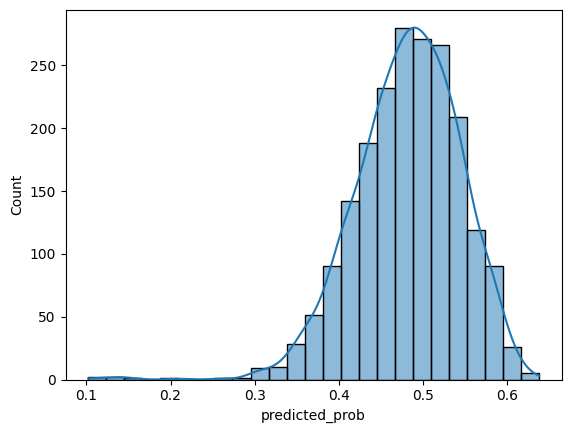

In [9]:
# Define the predictors and response
X = spotify_sample[ ['danceability', 'energy', 'loudness'] ]
y = (spotify_sample['popularity'] > 75).astype(int) # Binary outcome

# Add a constant to the model (intercept)
X = sm.add_constant(X)

# Fit the logistic regression model
logistic_model = sm.Logit(y, X).fit()

# Print the summary
logistic_model.summary()

# Predict probabilities
spotify_sample['predicted_prob'] = logistic_model.predict(X)

# Plot the predicted probabilities
sns.histplot(spotify_sample['predicted_prob'], bins=25, kde=True)
plt.show();


## Exercise 1.4: Logistic Regression

In [ ]:
# Define the predictors (runtime_in_minutes & votes) and response (rating > 7)


# Add a constant to the model (intercept)


# Fit the logistic regression model


# Print the summary


# Predict probabilities


# Plot the predicted probabilities



## Walkthrough 1.5: ANOVA

### One-way ANOVA

In [13]:
from statsmodels.formula.api import ols

# Choose some genres to compare
genres = ['pop', 'hip-hop', 'jazz', 'rock']

# Subset the data to focus only on these genres
spotify_sample_subset = spotify_sample[ spotify_sample['track_genre'].isin(genres)]

# Perform one-way ANOVA analyzing energy across different genres
anova_model = ols('energy ~ C(track_genre)', data=spotify_sample_subset).fit()
anova_table = sm.stats.anova_lm(anova_model, typ=2)
anova_table

,sum_sq,df,F,PR(>F)
C(track_genre),0.693407,3.0,9.11268,0.000011
Residual,5.275748,208.0,NaN,NaN


### Boxplot across groups

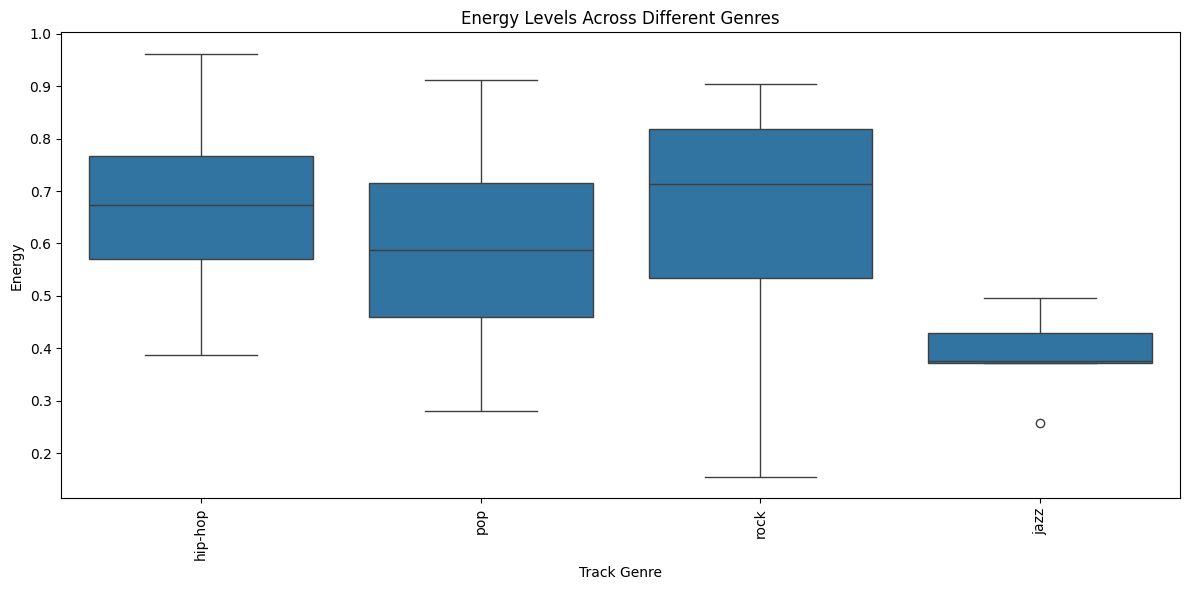

In [14]:
# Boxplot for visualization
plt.figure(figsize=(12, 6))
sns.boxplot(x='track_genre', y='energy', data=spotify_sample_subset)
plt.title('Energy Levels Across Different Genres')
plt.xlabel('Track Genre')
plt.ylabel('Energy')
plt.xticks(rotation=90);
# Adjust layout to prevent labels from being cut off
plt.tight_layout()

# Show the plot
plt.show();

### Two-way ANOVA

In [15]:
# Perform two-way ANOVA analyzing energy across genres and explicit content
twoway_anova_model = ols('energy ~ C(track_genre) * C(explicit)', data=spotify_sample_subset).fit()
anova_2_table = sm.stats.anova_lm(twoway_anova_model, typ=2)
anova_2_table

/usr/local/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 3, but rank is 2
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 3, but rank is 2
  warnings.warn('covariance of constraints does not have full '


,sum_sq,df,F,PR(>F)
C(track_genre),0.376918,3.0,4.905827,0.008295
C(explicit),0.008989,1.0,0.350974,0.554215
C(track_genre):C(explicit),0.036156,3.0,0.470592,0.625305
Residual,5.250099,205.0,NaN,NaN


### Boxplot across groups with color added

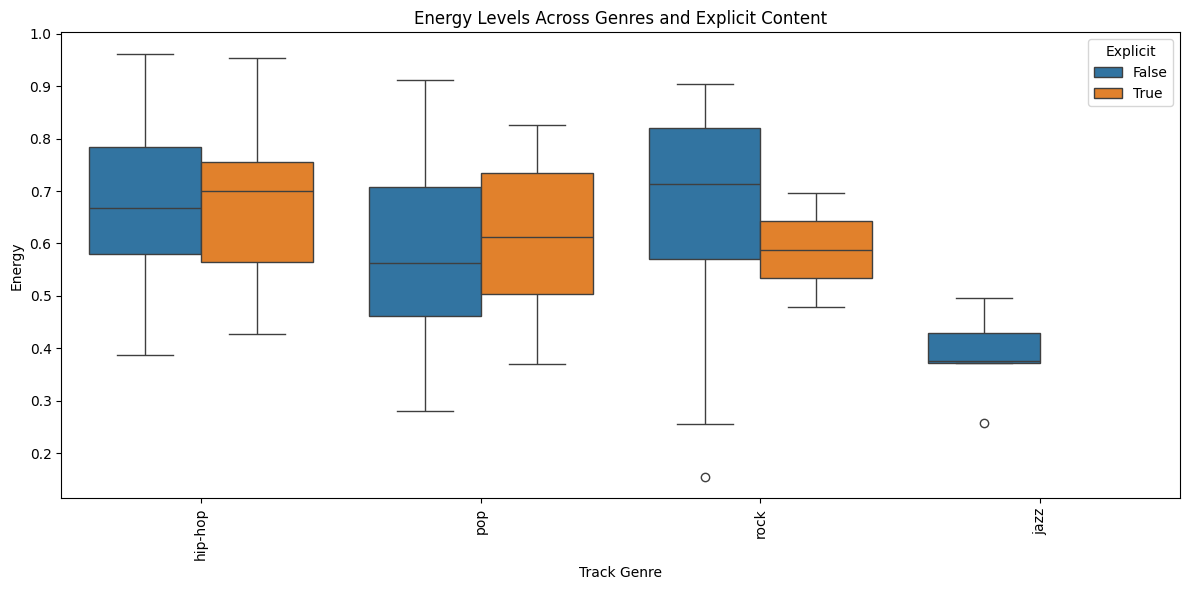

In [16]:
# Boxplot for visualization
plt.figure(figsize=(12, 6))
sns.boxplot(x='track_genre', y='energy', hue='explicit', data=spotify_sample_subset)
plt.title('Energy Levels Across Genres and Explicit Content')
plt.xlabel('Track Genre')
plt.ylabel('Energy')
plt.xticks(rotation=90)
plt.legend(title='Explicit')
plt.tight_layout()
plt.show();

## Exercise 1.5: ANOVA

### One-way ANOVA

In [ ]:
# Choose some genres to compare ('Action', 'Crime', 'Horror', 'Romance')


# Subset the data to focus only on these genres

# Perform one-way ANOVA analyzing rating across different genres



### Boxplot across groups

In [ ]:
# Boxplot for visualization



### Two-way ANOVA

In [ ]:
# Perform two-way ANOVA analyzing rating across genres and decades



### Boxplot across groups with color added

In [ ]:
# Some customization here to get the decades to appear in the appropriate order

# Define the ordered categories
decades = ['1940s', '1950s', '1960s', '1970s', '1980s', '1990s', '2000s', '2010s', '2020s']

# Convert 'decade' column to a categorical type with ordered categories
imdb_movie_sample_subset['decade'] = pd.Categorical(
    imdb_movie_sample_subset['decade'], 
    categories=decades, 
    ordered=True)

# Boxplot for visualization



## Walkthrough 2.1: Kruskal-Wallis and Mann-Whitney U Tests

### Kruskal-Wallis

In [ ]:
import scipy.stats as stats

# Perform Kruskal-Wallis Test on 'danceability' grouped by 'track_genre'



### Mann-Whitney U

In [ ]:
# Perform Mann-Whitney U Test on 'energy' for pop versus rock



## Exercise 2.1: Kruskal-Wallis and Mann-Whitney U Tests

### Kruskal-Wallis

In [ ]:
# Perform Kruskal-Wallis Test on 'rating' grouped by 'decade'



### Mann-Whitney U

In [ ]:
# Perform Mann-Whitney U Test on 'gross_in_dollars' for 1990s versus 2000s



## Walkthrough 2.2: Correlation and Regression Non-parametrics

### Spearman's Rank Correlation

In [ ]:
from scipy.stats import spearmanr, kendalltau
from sklearn.linear_model import TheilSenRegressor

# Filter numeric columns

# Calculate Spearman's rank correlation matrix


# Heatmap for Spearman's rank correlation matrix



### Kendall's Tau Correlation

In [ ]:
# Calculate Kendall's tau correlation matrix


# Heatmap for Kendall's tau correlation matrix



### Theil-Sen Robust Regression

In [ ]:
# Theil-Sen robust regression for 'danceability' and 
# 'energy' predicting 'popularity'



## Exercise 2.2: Correlation and Regression Non-parametrics

### Spearman's Rank Correlation

In [ ]:
# Filter numeric columns

# Calculate Spearman's rank correlation matrix


# Heatmap for Spearman's rank correlation matrix



### Kendall's Tau Correlation

In [ ]:
# Calculate Kendall's tau correlation matrix


# Heatmap for Kendall's tau correlation matrix



### Theil-Sen Robust Regression

In [ ]:
# Theil-Sen robust regression for 'votes' and 'runtime_in_minutes' 
# predicting 'rating'



## Walkthrough 2.3: Bootstrapping

In [ ]:
# Function to perform bootstrapping


# Perform bootstrapping on the 'energy' column

# Plot the distribution of bootstrap means



## Exercise 2.3: Bootstrapping

In [ ]:
# Perform bootstrapping on the 'runtime_in_minutes' column
# using the bootstrap function defined above

# Plot the distribution of bootstrap means



## Walkthrough 2.4: Confidence Intervals

In [ ]:
# Function to calculate bootstrap confidence intervals


# Calculate confidence intervals for the 'energy' column

# Plot the distribution of bootstrap means and confidence interval



## Exercise 2.4: Confidence Intervals

In [ ]:
# Calculate confidence intervals for the 'rating' column using the
# bootstrap_confidence_interval function defined above

# Plot the distribution of bootstrap means and confidence interval



## Walkthrough 2.5: Real-World Scenarios for Bootstrapping

**Music Industry Analytics**

*Objective*: Analyzing song popularity and estimating population mean popularity.

*Scenario*: You are a data scientist for a movie production company. Your role is to analyze movie ratings and predict the average rating of movies produced. By using bootstrapping techniques, you aim to estimate the mean movie rating and its variability to understand the unknown population mean.

*Bootstrapping Applications*:

- *Estimating Average Popularity*: Use bootstrapping to calculate the mean and confidence intervals of the popularity scores.
- *Assessing Variability*: Determine the variability in the means of song popularity.

In [ ]:
# Calculate bootstrap statistics for the 'popularity' column

# Function to calculate bootstrap statistics


# Plot the distribution of bootstrap means



## Exercise 2.5: Real-World Scenarios for Bootstrapping

**Film Industry Insights**

*Objective*: Evaluating movie gross revenue and estimating population mean gross revenue.

*Scenario*: You are a data scientist for a movie production company. Your role is to analyze movie gross revenue and predict the average gross revenue of movies produced. By using bootstrapping techniques, you aim to estimate the mean gross revenue and its variability to understand the unknown population mean.

*Bootstrapping Applications*:

- *Estimating Average Gross Revenue*: Use bootstrapping to calculate the mean and confidence intervals of movie gross revenue.
- *Assessing Variability*: Determine the variability in the means of movie gross revenue.

In [ ]:
# Calculate bootstrap statistics for the 'gross_in_dollars' column
# using the function called bootstrap_statistics defined above


# Plot the distribution of bootstrap means
